## **Website Analysis Python Project**

## Step 1 
## **Importing Liberaries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##  Step 2 
## **Reading dataset**

In [3]:
df = pd.read_csv("data-export (1).csv")


## Step 3 
## **Exploring Dataset**

In [4]:
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


## **Step 4**
## Transforming Dataset

In [10]:
# Assign the first row of the dataset as column headers
df.columns = df.iloc[0]

# Remove the first row since it is now used as the header
df = df.drop(index = 0).reset_index(drop = True)

# Rename columns to clean and meaningful names for analysis
df.columns = ["channel Group","DateHour","Users","Sessions","Engaged Sessions","Average engagement time per session",	"Engaged sessions per user","Events per session",	"Engagement rate",	"Event count"]

# Display the first few rows to verify the changes
df.head()

,channel Group,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [11]:
# Check the dataset structure, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   channel Group                        3182 non-null   object
 1   DateHour                             3182 non-null   object
 2   Users                                3182 non-null   object
 3   Sessions                             3182 non-null   object
 4   Engaged Sessions                     3182 non-null   object
 5   Average engagement time per session  3182 non-null   object
 6   Engaged sessions per user            3182 non-null   object
 7   Events per session                   3182 non-null   object
 8   Engagement rate                      3182 non-null   object
 9   Event count                          3182 non-null   object
dtypes: object(10)
memory usage: 248.7+ KB


In [18]:
# Convert the Object datatype of DateHour column to datetime format using the specified pattern
df["DateHour"] = pd.to_datetime(df["DateHour"],format = "%Y%m%d%H",errors = "coerce")

# Identify all columns that should contain numeric values
numeric_cols = df.columns.drop(["channel Group","DateHour"])

# Convert selected columns to numeric data types and handle invalid values
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric,errors = "coerce")

# Extract hour from DateHour to support time-based analysis
df["Hour"] = df["DateHour"].dt.hour

# Verify updated data types and check for missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   channel Group                        3182 non-null   object        
 1   DateHour                             3182 non-null   datetime64[ns]
 2   Users                                3182 non-null   int64         
 3   Sessions                             3182 non-null   int64         
 4   Engaged Sessions                     3182 non-null   int64         
 5   Average engagement time per session  3182 non-null   float64       
 6   Engaged sessions per user            3182 non-null   float64       
 7   Events per session                   3182 non-null   float64       
 8   Engagement rate                      3182 non-null   float64       
 9   Event count                          3182 non-null   int64         
 10  Hour        

In [19]:
# exploring dataset again
df.head()

,channel Group,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [20]:
# Generate descriptive statistics for numerical columns such as mean, min, max, and quartiles
df.describe()

,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441216,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


##  **Step 5**
## Exploratory Data Analysis

## 1 Sessions and Users over time

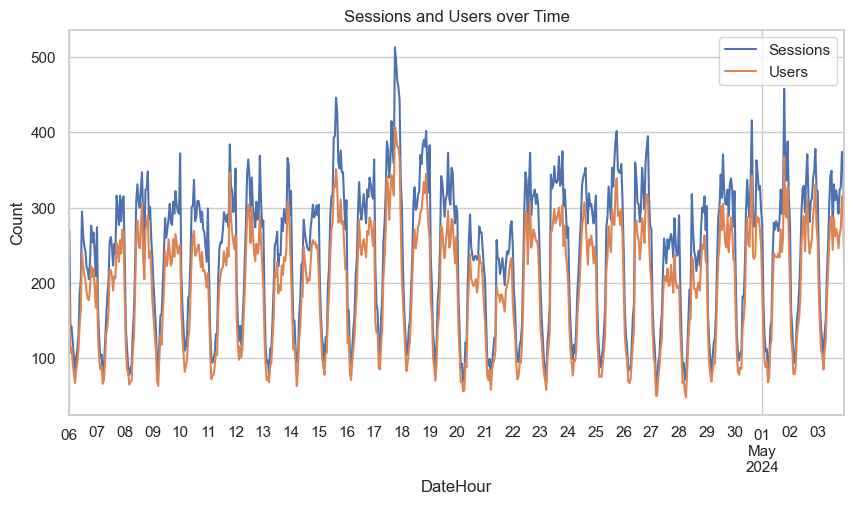

In [64]:
# Set the visual style for seaborn plots to improve readability
sns.set(style="whitegrid")

# Define the size of the figure for better visualization
plt.figure(figsize=(10, 5))

# Aggregate total sessions and users by DateHour and plot the trend over time
group = df.groupby("DateHour")[["Sessions", "Users"]].sum().plot(ax=plt.gca())

# Add a title to describe the purpose of the chart
plt.title("Sessions and Users over Time")

# Label the x-axis to represent the date and time dimension
plt.xlabel("DateHour")

# Label the y-axis to represent the aggregated count values
plt.ylabel("Count")

# Display the final plot
plt.show()


**Insights**

Sessions and users follow a similar trend over time, indicating a strong relationship between traffic volume and user growth.
Regular peaks and drops suggest time-based or campaign-driven traffic patterns.
Sudden spikes point to short-term marketing or content-driven activities.

**Business Recommendations**

Focus major campaigns and content launches during peak traffic periods to maximize impact.
Use low-traffic periods for targeted promotions to stabilize user activity.
Analyze spike periods to replicate successful marketing strategies across channels.

## 2 Total Users By Channel

C:\Users\b aiesha\AppData\Local\Temp\ipykernel_14316\4264470260.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


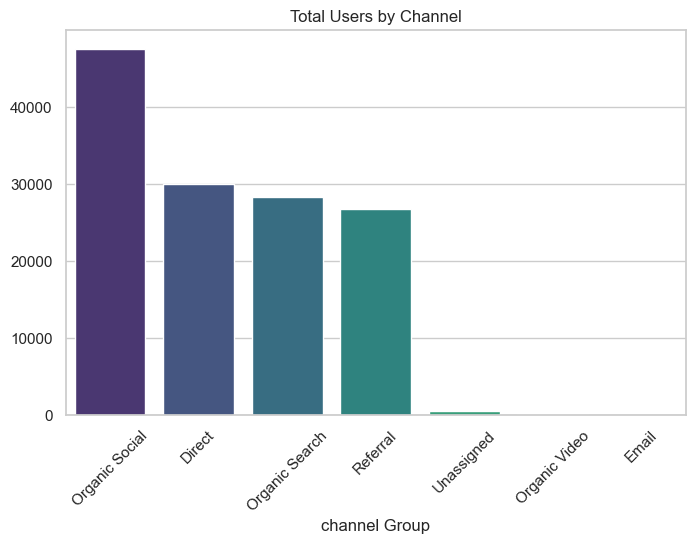

In [65]:
# Set the figure size to ensure the chart is clear and readable
plt.figure(figsize=(8, 5))

# Group the data by channel group and calculate total users for each channel
channel_grp = (
    df.groupby("channel Group")["Users"]
      .sum()
      .sort_values(ascending=False)
)

# Create a bar chart to visualize total users by channel group
sns.barplot(
    x=channel_grp.index,
    y=channel_grp.values,
    palette="viridis"
)

# Add a title to explain what the chart represents
plt.title("Total Users by Channel")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the final visualization
plt.show()


**Insights**

* Organic Social is the largest user acquisition channel, clearly outperforming others.
* Direct, Organic Search, and Referral contribute strong but secondary traffic volumes.
* Email, Organic Video, and Unassigned channels currently have minimal impact.

**Recommendations**

* Invest more in Organic Social content and campaigns to sustain and scale growth.
* Optimize SEO and referral partnerships to strengthen mid-performing channels.
* Reassess low-performing channels (Email, Video) or test new strategies before scaling.


## 3 Average Engagement Time by Channel

C:\Users\b aiesha\AppData\Local\Temp\ipykernel_14316\2145723816.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


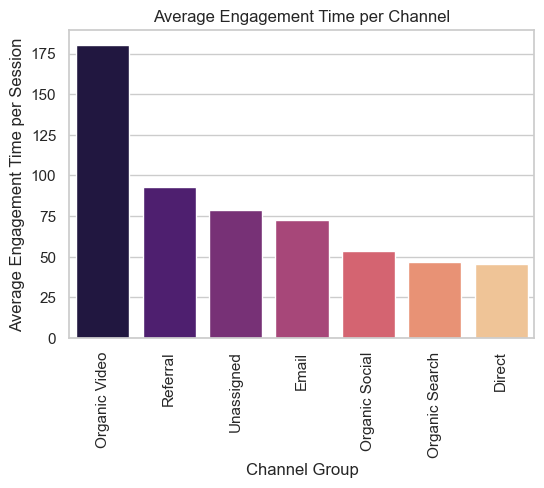

In [75]:
# Set the figure size for better visualization
plt.figure(figsize=(6, 4))

# Calculate the average engagement time per session for each channel group
chnl_grp_avg_eng = (
    df.groupby("channel Group")["Average engagement time per session"]
      .mean()
      .sort_values(ascending=False)
)

# Create a bar chart to compare average engagement time across channels
sns.barplot(
    x=chnl_grp_avg_eng.index,
    y=chnl_grp_avg_eng.values,
    palette="magma"
)

# Rotate x-axis labels to avoid overlap
plt.xticks(rotation=90)

# Add chart title and axis labels
plt.title("Average Engagement Time per Channel")
plt.ylabel("Average Engagement Time per Session")
plt.xlabel("Channel Group")

# Display the chart
plt.show()


**Insights

* Organic Video shows the highest engagement time, indicating very strong content quality.
* Referral and Email users are moderately engaged, suggesting trust-driven traffic.
* Direct and Organic Search bring volume but lower session engagement.

**Recommendations

* Scale Organic Video efforts and repurpose high-performing video content across channels.
* Strengthen referral and email strategies with personalized and value-driven messaging.
* Improve landing pages and content relevance for Direct and Search traffic to boost engagement.


## 4 Engagement Rate Distribution Across Traffic Channels

C:\Users\b aiesha\AppData\Local\Temp\ipykernel_14316\4168831657.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


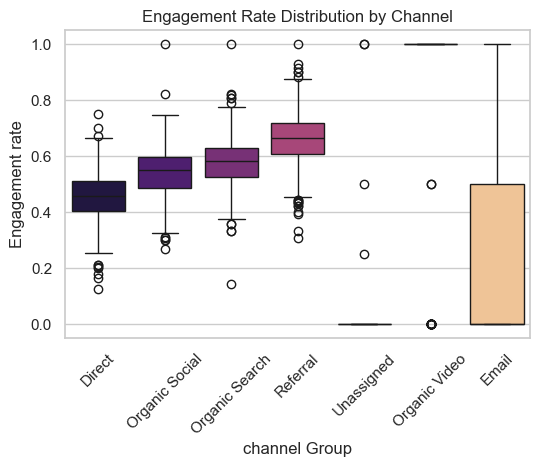

In [76]:
# Set the figure size for clear visualization
plt.figure(figsize=(6, 4))

# Create a box plot to analyze the distribution of engagement rate across channel groups
sns.boxplot(
    data=df,
    x="channel Group",
    y="Engagement rate",
    palette="magma"
)

# Add a descriptive title to the chart
plt.title("Engagement Rate Distribution by Channel")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.show()


**Insights

* Referral and Organic Search show the highest and most consistent engagement rates.
* Organic Social and Direct have moderate engagement with some variability.
* Email and Unassigned channels show wide dispersion, indicating inconsistent performance.

**Recommendations

* Prioritize and scale Referral and SEO initiatives to maximize high-quality traffic.
* Optimize Organic Social creatives and targeting to reduce engagement variability.
* Audit Email and Unassigned traffic sources to improve consistency or reallocate spend.


## 5 Engage vs Non Engage sessions by Channel

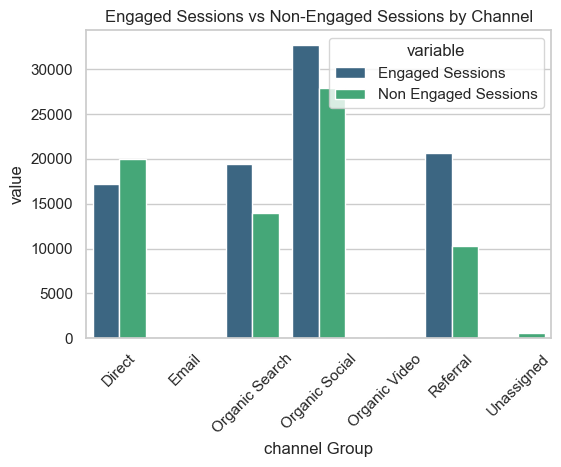

In [77]:
# Aggregate total sessions and engaged sessions for each channel group
df2 = df.groupby("channel Group")[["Sessions", "Engaged Sessions"]].sum().reset_index()

# Calculate non-engaged sessions by subtracting engaged sessions from total sessions
df2["Non Engaged Sessions"] = df2["Sessions"] - df2["Engaged Sessions"]

# Reshape the data to long format for grouped bar chart visualization
df2_melted = df2.melt(
    id_vars="channel Group",
    value_vars=["Engaged Sessions", "Non Engaged Sessions"]
)

# Set figure size for better clarity
plt.figure(figsize=(6, 4))

# Create a grouped bar chart to compare engaged and non-engaged sessions
sns.barplot(
    data=df2_melted,
    x="channel Group",
    y="value",
    hue="variable",
    palette = "viridis"
)

# Add title and format x-axis labels
plt.title("Engaged Sessions vs Non-Engaged Sessions by Channel")
plt.xticks(rotation=45)

# Display the plot
plt.show()


** Simple Insights**

1. **Organic Social** has the highest engaged sessions, showing strong audience interaction on social platforms.
2. **Direct traffic** has more non-engaged sessions than engaged ones, indicating weaker user intent or landing page issues.
3. **Referral traffic** shows a good engagement ratio with relatively low non-engaged sessions compared to engaged sessions.

** Business Recommendations:**

1. Invest more in **Organic Social strategies** (content, campaigns, consistency) to scale already strong engagement.
2. Optimize **Direct traffic landing pages** (clear messaging, faster load time, strong CTAs) to reduce non-engaged sessions.
3. Strengthen **Referral partnerships** since they bring higher-quality, more engaged users.


## 6 Traffic by Hour and Channel

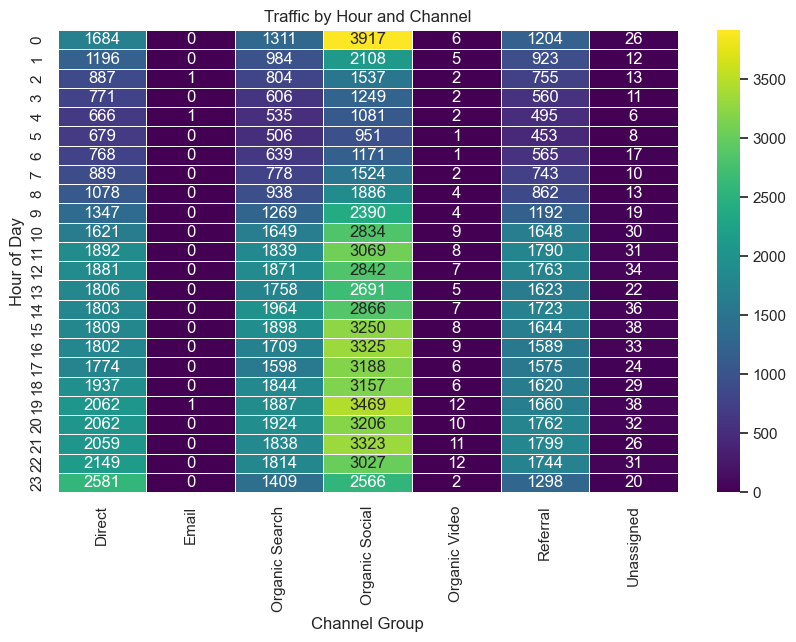

In [81]:
# Aggregate total sessions by hour and channel group and reshape the data for heatmap visualization
heatmap_data = (
    df.groupby(["Hour", "channel Group"])["Sessions"]
      .sum()
      .unstack()
      .fillna(0)
)

# Set figure size for better readability
plt.figure(figsize=(10, 6))

# Create a heatmap to visualize traffic intensity across hours and channels
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    linewidths=0.5,
    annot=True,
    fmt=".0f"
)

# Add title and axis labels
plt.title("Traffic by Hour and Channel")
plt.xlabel("Channel Group")
plt.ylabel("Hour of Day")

# Display the heatmap
plt.show()


** Insights**

1. **Organic Social traffic peaks from late morning to evening (≈10 AM–9 PM)**, showing strong time-based engagement.
2. **Direct and Organic Search traffic steadily increase throughout the day**, with highest values in the evening hours.
3. **Email and Organic Video traffic remain consistently low across all hours**, indicating limited impact.

** Business Recommendations:**

1. Schedule **Organic Social posts and campaigns between 10 AM and 9 PM** to maximize reach and engagement.
2. Focus SEO and performance improvements for **evening hours**, when Direct and Organic Search traffic is highest.
3. Re-evaluate **Email and Organic Video strategies** (content, targeting, timing) or reallocate budget to higher-performing channels.


##  7 Relationship Between Sessions and Engagement Rate Over Time

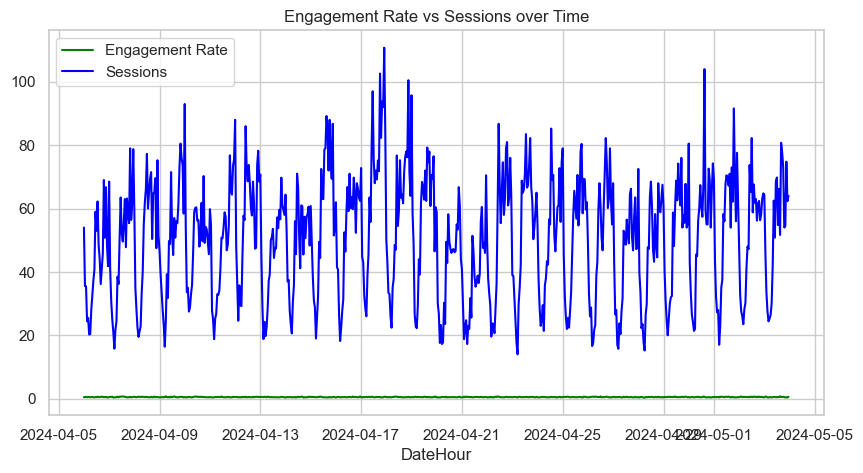

In [70]:
# Aggregate average engagement rate and sessions over time
df_plot = (
    df.groupby("DateHour")[["Engagement rate", "Sessions"]]
      .mean()
      .reset_index()
)

# Set the figure size for clear visualization
plt.figure(figsize=(10, 5))

# Plot engagement rate trend over time
plt.plot(
    df_plot["DateHour"],
    df_plot["Engagement rate"],
    label="Engagement Rate",
    color="green"
)

# Plot sessions trend over time
plt.plot(
    df_plot["DateHour"],
    df_plot["Sessions"],
    label="Sessions",
    color="blue"
)

# Add title and axis label
plt.title("Engagement Rate vs Sessions over Time")
plt.xlabel("DateHour")

# Display legend to differentiate lines
plt.legend()

# Add grid for better readability
plt.grid(True)

# Display the plot
plt.show()


** Insights:**

1. **Sessions show strong daily fluctuations**, with clear peaks and dips, indicating time-based user activity patterns.
2. **Engagement rate remains relatively stable over time**, despite large changes in session volume.
3. **High session spikes do not always correspond to higher engagement**, suggesting traffic quality varies.

** Business Recommendations:**

1. Identify **time periods with both high sessions and steady engagement** and prioritize campaigns during those windows.
2. Improve **user experience and content quality** during high-traffic spikes to convert volume into better engagement.
3. Segment traffic sources during session peaks to **filter low-quality traffic and focus on high-intent users**.


**Conclusion (Dataset Summary):**

The analysis shows that **Organic Social and Organic Search are the strongest traffic drivers**, consistently delivering high sessions
and better engagement compared to other channels. User activity follows **clear time-based patterns**, with traffic peaking from late
morning to evening, while engagement rate remains relatively stable across time. Although some channels like Direct bring high volume,
they also contribute to higher non-engaged sessions, indicating opportunities for optimization. Overall, the dataset highlights that
**traffic quality matters more than volume**, and focusing on high-performing channels, optimal time windows, and user experience
improvements will lead to better engagement and business outcomes.
